In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load config from Day 2
with open('../models/config.json', 'r') as f:
    config = json.load(f)

device = torch.device(config['device'])

print("Config loaded successfully!")
print(f"Device       : {device}")
print(f"Image size   : {config['img_size']}")
print(f"Batch size   : {config['batch_size']}")
print(f"Classes      : {config['class_names']}")

Config loaded successfully!
Device       : mps
Image size   : 224
Batch size   : 32
Classes      : ['NORMAL', 'PNEUMONIA']


In [2]:
IMG_SIZE   = config['img_size']
BATCH_SIZE = config['batch_size']
TRAIN_DIR  = config['train_dir']
TEST_DIR   = config['test_dir']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("DataLoaders ready!")

Train batches : 163
Test batches  : 20
DataLoaders ready!


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        # Classification layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialize model
model = SimpleCNN().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture ready!")
print(f"Total parameters: {total_params:,}")
print(f"Model is on: {next(model.parameters()).device}")
print(f"\n{model}")

Model architecture ready!
Total parameters: 25,784,130
Model is on: mps:0

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [4]:
# Class weights to handle imbalance (NORMAL:1342, PNEUMONIA:3876)
class_weights = torch.tensor([3876/1342, 1342/3876]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Loss function : CrossEntropyLoss with class weights")
print(f"Class weights : NORMAL={3876/1342:.2f}, PNEUMONIA={1342/3876:.2f}")
print("Optimizer     : Adam (lr=0.001)")
print("Scheduler     : StepLR (decay every 3 epochs)")

Loss function : CrossEntropyLoss with class weights
Class weights : NORMAL=2.89, PNEUMONIA=0.35
Optimizer     : Adam (lr=0.001)
Scheduler     : StepLR (decay every 3 epochs)


In [5]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss    += loss.item()
            _, predicted   = outputs.max(1)
            train_total   += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            loop.set_postfix(loss=f"{loss.item():.3f}")
        
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item()
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        # Record metrics
        train_acc = 100 * train_correct / train_total
        val_acc   = 100 * val_correct   / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(test_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    return history

# Train for 5 epochs
print("Starting training on MPS GPU...")
print("="*60)
history = train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=5)

Starting training on MPS GPU...


Epoch 1/5: 100%|██████████| 163/163 [00:30<00:00,  5.36it/s, loss=0.221]


Epoch 1/5 -> Train Loss: 0.3555 | Train Acc: 73.35% | Val Loss: 0.3416 | Val Acc: 85.42%


Epoch 2/5: 100%|██████████| 163/163 [00:27<00:00,  5.98it/s, loss=0.244]


Epoch 2/5 -> Train Loss: 0.1857 | Train Acc: 87.90% | Val Loss: 0.7269 | Val Acc: 77.08%


...

Epoch 3/5 -> Train Loss: 0.1698 | Train Acc: 90.05% | Val Loss: 0.3925 | Val Acc: 84.29%


Epoch 4/5: 100%|██████████| 163/163 [00:27<00:00,  5.88it/s, loss=0.059]


Epoch 4/5 -> Train Loss: 0.1149 | Train Acc: 93.46% | Val Loss: 0.3773 | Val Acc: 85.42%


Epoch 5/5: 100%|██████████| 163/163 [00:27<00:00,  5.94it/s, loss=0.079]


Epoch 5/5 -> Train Loss: 0.1139 | Train Acc: 93.73% | Val Loss: 0.4003 | Val Acc: 83.65%


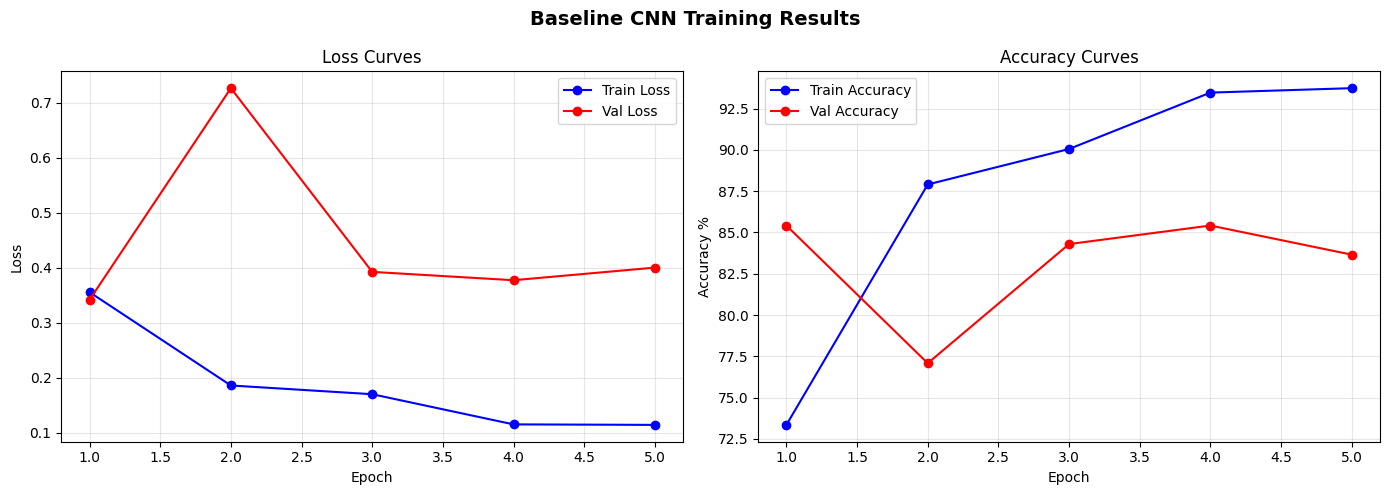

Best Val Accuracy : 85.42%
Final Train Acc   : 93.73%
Gap (overfit check): 10.08%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 6)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline CNN Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best Val Accuracy : {max(history['val_acc']):.2f}%")
print(f"Final Train Acc   : {history['train_acc'][-1]:.2f}%")
print(f"Gap (overfit check): {history['train_acc'][-1] - history['val_acc'][-1]:.2f}%")

In [7]:
# Save the baseline model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'val_accuracy': max(history['val_acc']),
    'architecture': 'SimpleCNN'
}, '../models/baseline_cnn.pth')

print("Baseline model saved to models/baseline_cnn.pth")
print(f"Best validation accuracy: {max(history['val_acc']):.2f}%")
print("\nDay 3 complete! Tomorrow we build ResNet50 and beat this score.")

Baseline model saved to models/baseline_cnn.pth
Best validation accuracy: 85.42%

Day 3 complete! Tomorrow we build ResNet50 and beat this score.
